<a href="https://colab.research.google.com/github/sungheetha-it/AppsAndTools/blob/main/Agricultural_Image_and_Video_Streaming.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Agricultural Image and Video Streaming Dashboard

For this dashboard, we'll use a synthetic dataset that simulates various agricultural parameters influencing crop yield. This dataset includes features commonly derived from remote sensing, environmental monitoring, and field observations, which are relevant to insights obtained from agricultural imaging and video streaming.

This approach allows us to demonstrate a wide range of visualization techniques relevant to agricultural data analysis without requiring external API keys or complex data ingestion setups specific to image/video streaming itself.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set a random seed for reproducibility
np.random.seed(42)

# Number of data points
n_samples = 1000

# Generate synthetic data
data = {
    'Farm_ID': np.arange(n_samples),
    'Crop_Type': np.random.choice(['Wheat', 'Corn', 'Soybean', 'Rice'], n_samples, p=[0.3, 0.3, 0.2, 0.2]),
    'Soil_Type': np.random.choice(['Loam', 'Clay', 'Sand', 'Silt'], n_samples, p=[0.4, 0.2, 0.2, 0.2]),
    'Region': np.random.choice(['North', 'South', 'East', 'West'], n_samples, p=[0.25, 0.25, 0.25, 0.25]),
    'Season': np.random.choice(['Spring', 'Summer', 'Autumn'], n_samples, p=[0.4, 0.4, 0.2]),
    'Rainfall_mm': np.random.normal(loc=400, scale=100, size=n_samples).astype(int).clip(100, 700),
    'Temperature_C': np.random.normal(loc=20, scale=5, size=n_samples).astype(int).clip(10, 35),
    'Pesticide_Use_kg': np.random.normal(loc=5, scale=2, size=n_samples).clip(0, 10),
    'Fertilizer_Use_kg': np.random.normal(loc=15, scale=5, size=n_samples).clip(5, 25),
    'Irrigation': np.random.choice([True, False], n_samples, p=[0.6, 0.4]),
    'Image_Analysis_Score': np.random.uniform(low=0.5, high=0.95, size=n_samples) # Proxy for plant health/vigor from images
}

df = pd.DataFrame(data)

# Introduce some correlation with yield
df['Yield_kg_per_acre'] = (
    1000  # Base yield
    + (df['Rainfall_mm'] * 0.5)
    + (df['Temperature_C'] * 10)
    + (df['Pesticide_Use_kg'] * -50) # Too much pesticide can reduce yield
    + (df['Fertilizer_Use_kg'] * 30)
    + (df['Image_Analysis_Score'] * 500) # Higher image score means better yield
    + np.random.normal(0, 100, n_samples) # Noise
)

# Adjust yield based on Crop Type, Soil Type, Irrigation, Season
# Wheat and Rice generally have lower yields than Corn and Soybean
df.loc[df['Crop_Type'] == 'Wheat', 'Yield_kg_per_acre'] *= 0.8
df.loc[df['Crop_Type'] == 'Rice', 'Yield_kg_per_acre'] *= 0.9
df.loc[df['Crop_Type'] == 'Corn', 'Yield_kg_per_acre'] *= 1.2
df.loc[df['Crop_Type'] == 'Soybean', 'Yield_kg_per_acre'] *= 1.1

# Better soil types lead to higher yields
df.loc[df['Soil_Type'] == 'Loam', 'Yield_kg_per_acre'] *= 1.1
df.loc[df['Soil_Type'] == 'Sand', 'Yield_kg_per_acre'] *= 0.9

# Irrigation increases yield
df.loc[df['Irrigation'] == True, 'Yield_kg_per_acre'] *= 1.1

# Adjust for season
df.loc[df['Season'] == 'Autumn', 'Yield_kg_per_acre'] *= 0.9

df['Yield_kg_per_acre'] = df['Yield_kg_per_acre'].clip(500, 5000).astype(int)

df.head()

,Farm_ID,Crop_Type,Soil_Type,Region,Season,Rainfall_mm,Temperature_C,Pesticide_Use_kg,Fertilizer_Use_kg,Irrigation,Image_Analysis_Score,Yield_kg_per_acre
0,0,Corn,Loam,South,Summer,532,16,4.631708,15.461884,True,0.514429,2672
1,1,Rice,Clay,North,Summer,431,20,2.739643,7.176889,True,0.775540,2013
2,2,Soybean,Silt,West,Spring,339,20,5.546021,15.717133,True,0.822278,2405
3,3,Corn,Sand,North,Summer,445,22,0.850720,19.357622,False,0.687537,2605
4,4,Wheat,Silt,South,Summer,354,18,4.816086,8.744004,True,0.840783,1763


### Insight 1: Dataset Overview - First 5 Rows

In [2]:
display(df.head())

,Farm_ID,Crop_Type,Soil_Type,Region,Season,Rainfall_mm,Temperature_C,Pesticide_Use_kg,Fertilizer_Use_kg,Irrigation,Image_Analysis_Score,Yield_kg_per_acre
0,0,Corn,Loam,South,Summer,532,16,4.631708,15.461884,True,0.514429,2672
1,1,Rice,Clay,North,Summer,431,20,2.739643,7.176889,True,0.775540,2013
2,2,Soybean,Silt,West,Spring,339,20,5.546021,15.717133,True,0.822278,2405
3,3,Corn,Sand,North,Summer,445,22,0.850720,19.357622,False,0.687537,2605
4,4,Wheat,Silt,South,Summer,354,18,4.816086,8.744004,True,0.840783,1763


### Insight 2: Dataset Information - Data Types and Missing Values

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Farm_ID               1000 non-null   int64  
 1   Crop_Type             1000 non-null   object 
 2   Soil_Type             1000 non-null   object 
 3   Region                1000 non-null   object 
 4   Season                1000 non-null   object 
 5   Rainfall_mm           1000 non-null   int64  
 6   Temperature_C         1000 non-null   int64  
 7   Pesticide_Use_kg      1000 non-null   float64
 8   Fertilizer_Use_kg     1000 non-null   float64
 9   Irrigation            1000 non-null   bool   
 10  Image_Analysis_Score  1000 non-null   float64
 11  Yield_kg_per_acre     1000 non-null   int64  
dtypes: bool(1), float64(3), int64(4), object(4)
memory usage: 87.0+ KB


### Insight 3: Descriptive Statistics for Numerical Features

In [4]:
display(df.describe())

,Farm_ID,Rainfall_mm,Temperature_C,Pesticide_Use_kg,Fertilizer_Use_kg,Image_Analysis_Score,Yield_kg_per_acre
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,499.500000,399.194000,19.412000,4.906049,14.802816,0.727624,2053.813000
std,288.819436,101.951707,4.783423,1.995763,4.985946,0.128838,469.031533
min,0.000000,107.000000,10.000000,0.000000,5.000000,0.500963,949.000000
25%,249.750000,326.000000,16.000000,3.524581,11.241181,0.614376,1693.000000
50%,499.500000,400.000000,19.500000,4.901234,14.726268,0.727968,1994.000000
75%,749.250000,468.000000,23.000000,6.252921,18.498725,0.839753,2378.250000
max,999.000000,700.000000,35.000000,10.000000,25.000000,0.949853,3612.000000


### Insight 4: Distribution of Crop Types

/tmp/ipykernel_925/632271009.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Crop_Type', palette='viridis')


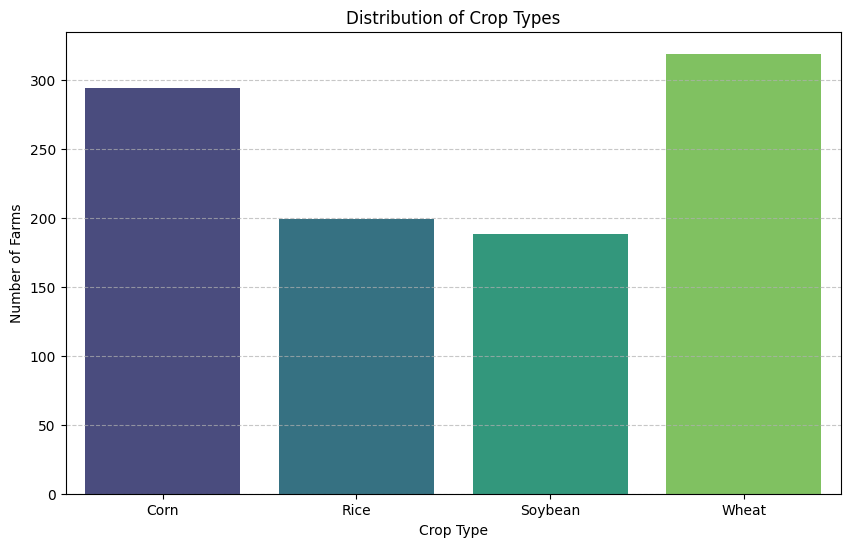

In [5]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Crop_Type', palette='viridis')
plt.title('Distribution of Crop Types')
plt.xlabel('Crop Type')
plt.ylabel('Number of Farms')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Insight 5: Distribution of Yield per Acre

/tmp/ipykernel_925/4224505207.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(data=df, x='Yield_kg_per_acre', bins=30, kde=True, palette='coolwarm')


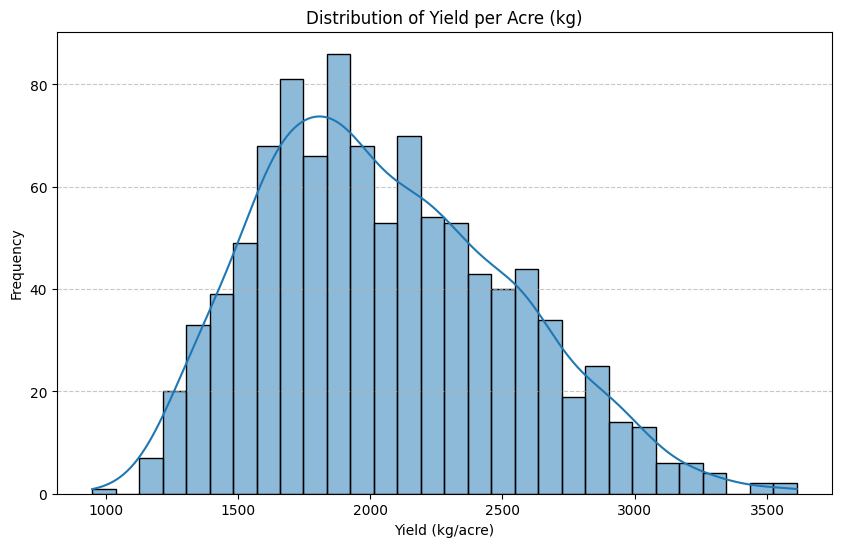

In [6]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Yield_kg_per_acre', bins=30, kde=True, palette='coolwarm')
plt.title('Distribution of Yield per Acre (kg)')
plt.xlabel('Yield (kg/acre)')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Insight 6: Yield Variation by Crop Type

/tmp/ipykernel_925/3666315086.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Crop_Type', y='Yield_kg_per_acre', palette='plasma')


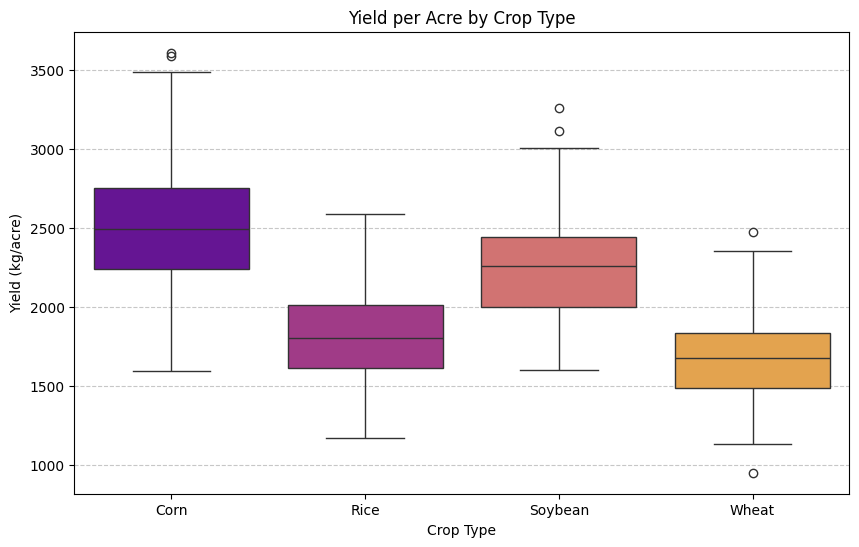

In [7]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Crop_Type', y='Yield_kg_per_acre', palette='plasma')
plt.title('Yield per Acre by Crop Type')
plt.xlabel('Crop Type')
plt.ylabel('Yield (kg/acre)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Insight 7: Average Yield by Soil Type

/tmp/ipykernel_925/3374050136.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_yield_soil, x='Soil_Type', y='Yield_kg_per_acre', palette='cividis')


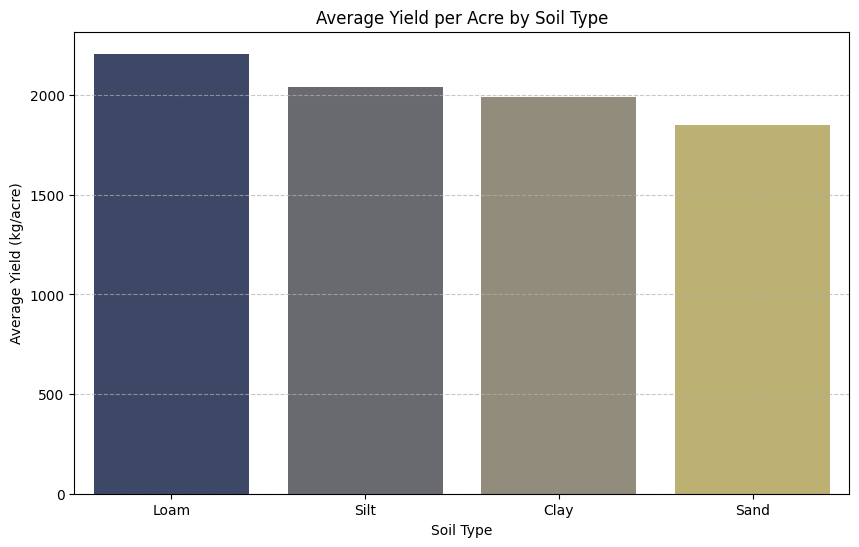

In [8]:
plt.figure(figsize=(10, 6))
avg_yield_soil = df.groupby('Soil_Type')['Yield_kg_per_acre'].mean().sort_values(ascending=False).reset_index()
sns.barplot(data=avg_yield_soil, x='Soil_Type', y='Yield_kg_per_acre', palette='cividis')
plt.title('Average Yield per Acre by Soil Type')
plt.xlabel('Soil Type')
plt.ylabel('Average Yield (kg/acre)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Insight 8: Distribution of Rainfall

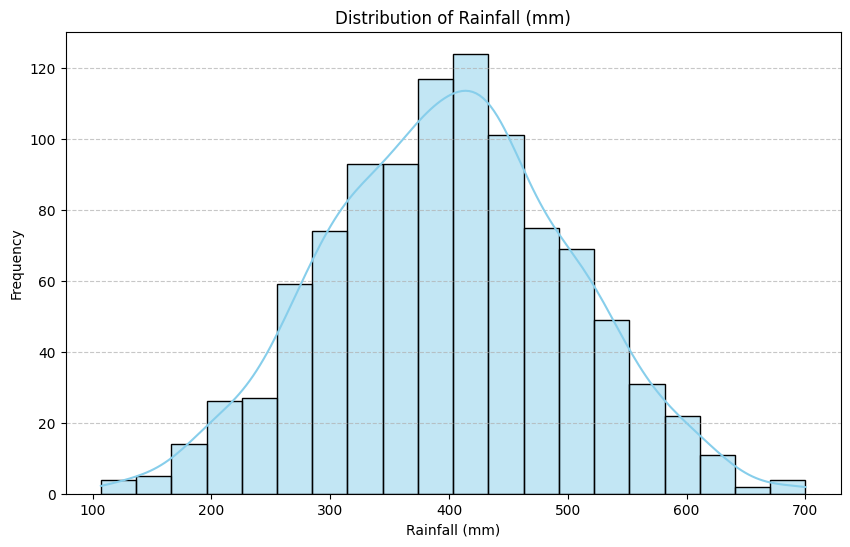

In [9]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Rainfall_mm', bins=20, kde=True, color='skyblue')
plt.title('Distribution of Rainfall (mm)')
plt.xlabel('Rainfall (mm)')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Insight 9: Distribution of Temperature

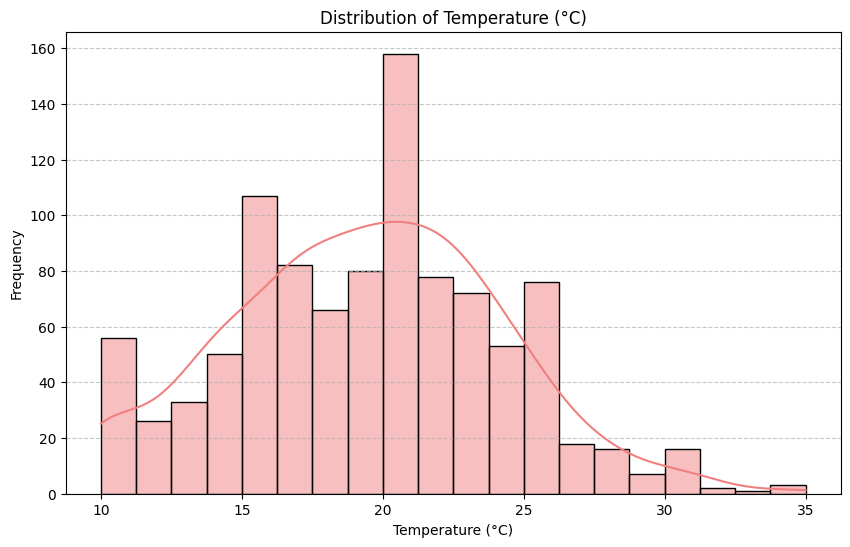

In [10]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Temperature_C', bins=20, kde=True, color='lightcoral')
plt.title('Distribution of Temperature (°C)')
plt.xlabel('Temperature (°C)')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Insight 10: Relationship between Yield and Rainfall

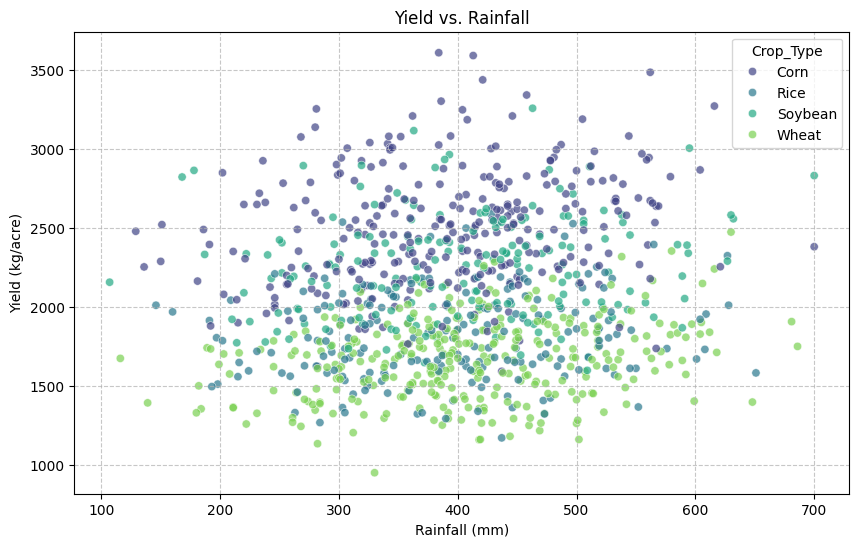

In [11]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Rainfall_mm', y='Yield_kg_per_acre', hue='Crop_Type', palette='viridis', alpha=0.7)
plt.title('Yield vs. Rainfall')
plt.xlabel('Rainfall (mm)')
plt.ylabel('Yield (kg/acre)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Insight 11: Relationship between Yield and Temperature

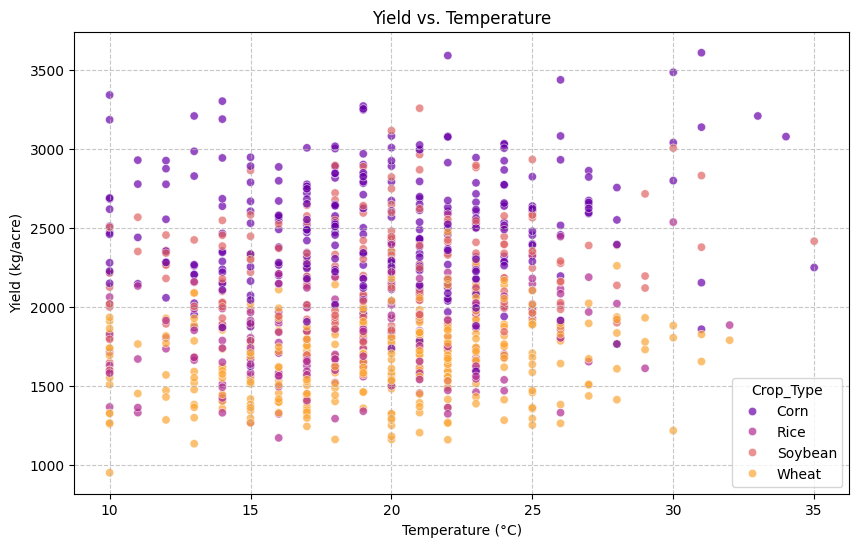

In [12]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Temperature_C', y='Yield_kg_per_acre', hue='Crop_Type', palette='plasma', alpha=0.7)
plt.title('Yield vs. Temperature')
plt.xlabel('Temperature (°C)')
plt.ylabel('Yield (kg/acre)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Insight 12: Impact of Pesticide Use on Yield

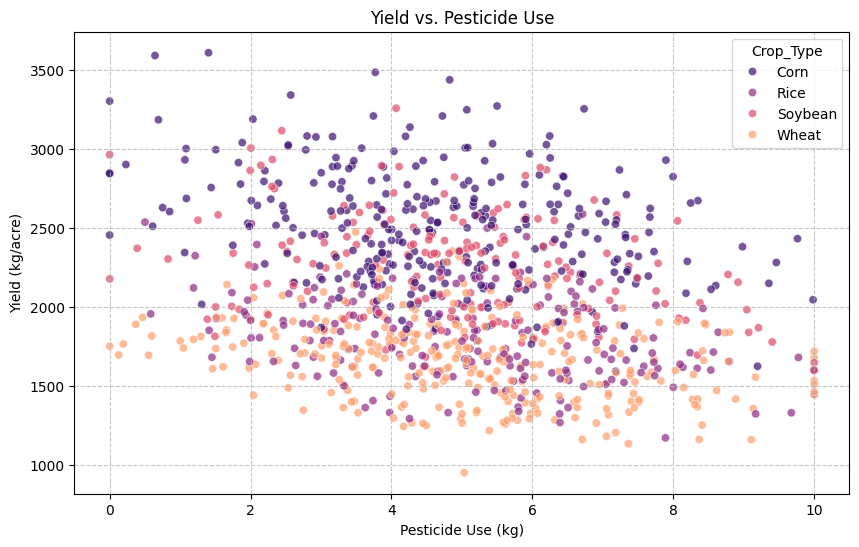

In [13]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Pesticide_Use_kg', y='Yield_kg_per_acre', hue='Crop_Type', palette='magma', alpha=0.7)
plt.title('Yield vs. Pesticide Use')
plt.xlabel('Pesticide Use (kg)')
plt.ylabel('Yield (kg/acre)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Insight 13: Average Yield by Region

/tmp/ipykernel_925/1309259839.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_yield_region, x='Region', y='Yield_kg_per_acre', palette='tab10')


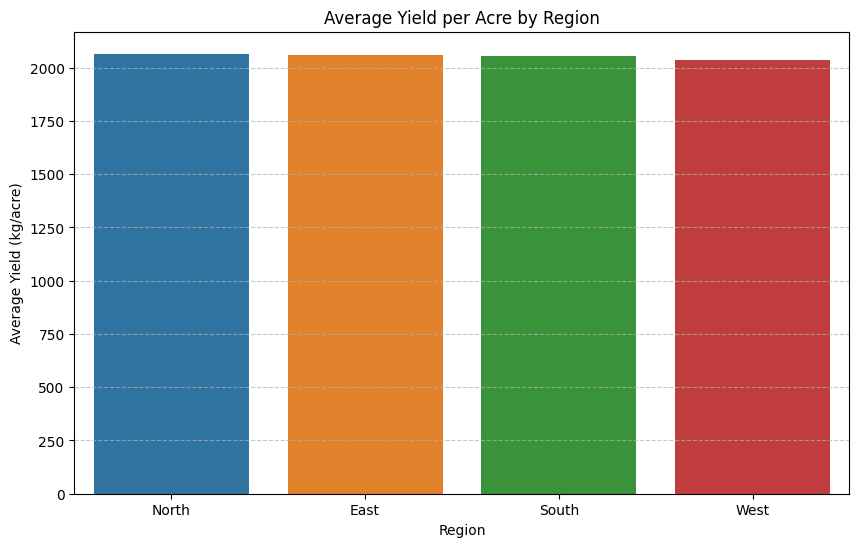

In [14]:
plt.figure(figsize=(10, 6))
avg_yield_region = df.groupby('Region')['Yield_kg_per_acre'].mean().sort_values(ascending=False).reset_index()
sns.barplot(data=avg_yield_region, x='Region', y='Yield_kg_per_acre', palette='tab10')
plt.title('Average Yield per Acre by Region')
plt.xlabel('Region')
plt.ylabel('Average Yield (kg/acre)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Insight 14: Yield Comparison between Irrigated and Non-Irrigated Farms

/tmp/ipykernel_925/2875990030.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Irrigation', y='Yield_kg_per_acre', palette='cool')


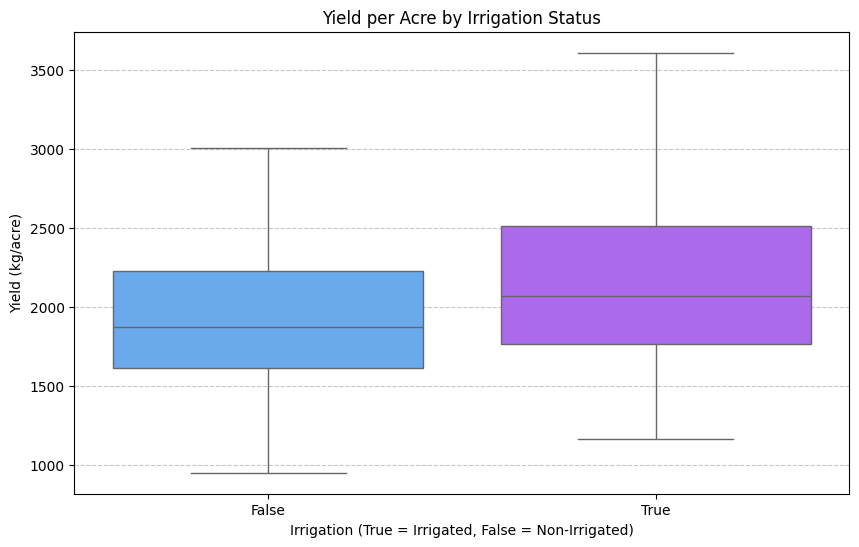

In [15]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Irrigation', y='Yield_kg_per_acre', palette='cool')
plt.title('Yield per Acre by Irrigation Status')
plt.xlabel('Irrigation (True = Irrigated, False = Non-Irrigated)')
plt.ylabel('Yield (kg/acre)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Insight 15: Correlation Matrix of Numerical Features

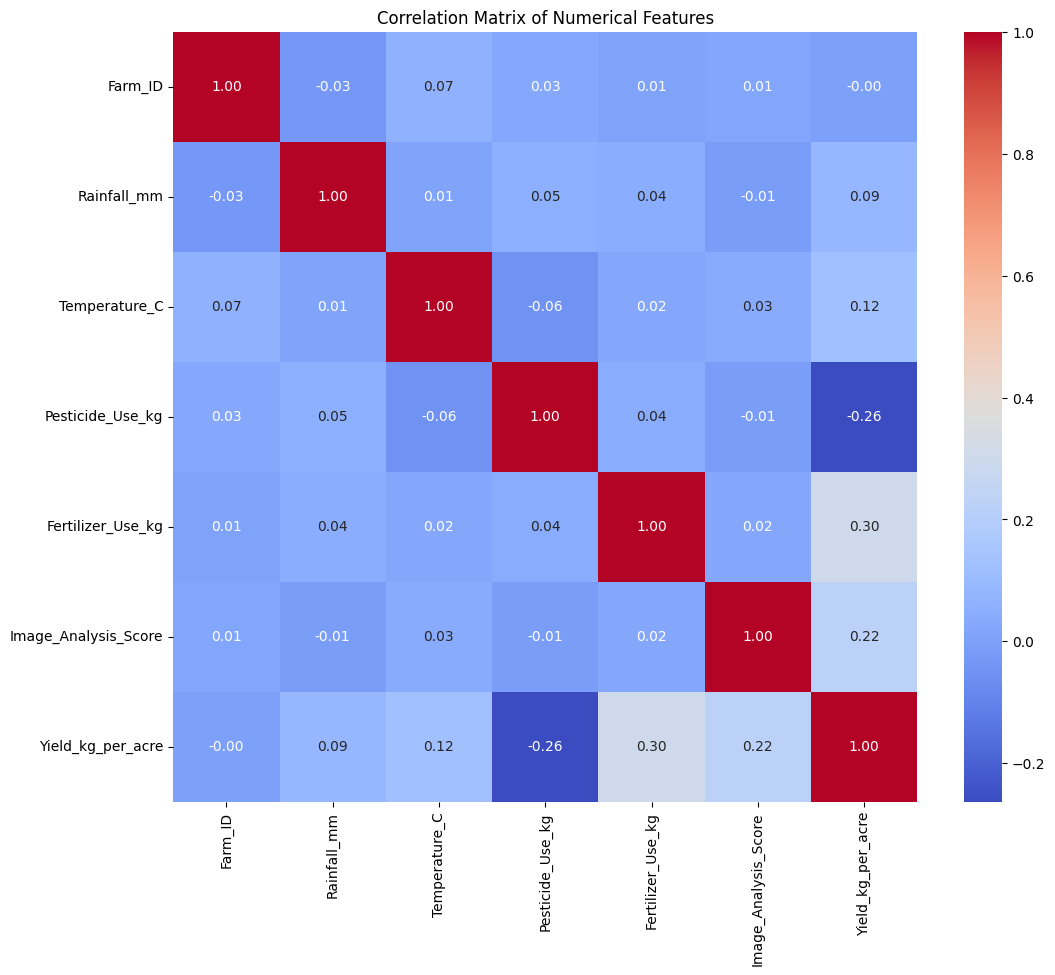

In [16]:
plt.figure(figsize=(12, 10))
numerical_df = df.select_dtypes(include=[np.number])
sns.heatmap(numerical_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()